# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

   Dataset ini digunakan untuk memprediksi risiko penyakit [Diabetes / Heart Disease] berdasarkan indikator kesehatan pasien. Eksperimen ini bertujuan untuk menganalisis karakteristik data melalui EDA dan melakukan tahapan preprocessing agar data siap digunakan dalam pemodelan Machine Learning menggunakan MLflow.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
data_path = "diabetes_raw/diabetes.csv"

df = pd.read_csv(data_path)

print("Data berhasil dimuat!")
display(df.head())

Data berhasil dimuat!


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Jumlah Missing Values per Kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Jumlah Data Duplikat: 0

Statistik Deskriptif:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


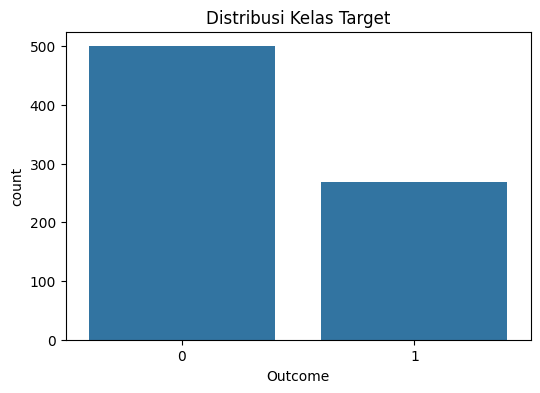

In [5]:
# A. Memeriksa Missing Values dan Duplikat
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum())
print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

# B. Analisis Deskriptif
print("\nStatistik Deskriptif:")
display(df.describe())

# C. Visualisasi Distribusi Target (Contoh jika kolom target bernama 'Outcome' atau 'HeartDisease')
# Sesuaikan nama kolom target sesuai dataset asli yang kamu download
target_col = 'Outcome'

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col)
plt.title("Distribusi Kelas Target")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
# A. Menangani Duplikat jika ada
df = df.drop_duplicates()

# B. Pemisahan Fitur (X) dan Target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# C. Handling Missing Values / Nilai 0 yang tidak masuk akal (jika ada pada fitur medis seperti Insulin/BloodPressure)
# Contoh: Mengganti nilai 0 dengan median pada kolom tertentu
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zero:
    if col in X.columns:
        X[col] = X[col].replace(0, X[col].median())

# D. Standarisasi Fitur Numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# E. Menggabungkan kembali menjadi dataset preprocessing yang bersih
df_clean = X_scaled_df.copy()
df_clean[target_col] = y.values

# F. Menyimpan hasil preprocessing ke folder output
os.makedirs("preprocessing/diabetes_preprocessing", exist_ok=True)
df_clean.to_csv("preprocessing/diabetes_preprocessing/data_clean.csv", index=False)
print("Data preprocessing berhasil disimpan!")

Data preprocessing berhasil disimpan!


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
import sys

def run_preprocessing(input_path, output_dir):
    print(f"Memulai otomatisasi preprocessing untuk: {input_path}")

    # Load Data
    if not os.path.exists(input_path):
        print(f"Error: File {input_path} tidak ditemukan!")
        sys.exit(1)

    df = pd.read_csv(input_path)
    target_col = 'Outcome'

    # Hapus Duplikat
    df = df.drop_duplicates()

    # Separasi X dan y
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Imputasi nilai 0 dengan median
    cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    for col in cols_with_zero:
        if col in X.columns:
            X[col] = X[col].replace(0, X[col].median())

    # Standarisasi
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

    # Rekonsiliasi Data
    df_clean = X_scaled_df.copy()
    df_clean[target_col] = y.values

    # Simpan Output
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, "data_clean.csv")
    df_clean.to_csv(output_file, index=False)

    print(f"Pre-processing Selesai! File disimpan di: {output_file}")


if __name__ == "__main__":
    INPUT = "diabetes_raw/diabetes.csv"
    OUTPUT_DIR = "preprocessing/diabetes_preprocessing"

    # Menjalankan mesin dengan input dan output di atas
    run_preprocessing(INPUT, OUTPUT_DIR)

Memulai otomatisasi preprocessing untuk: diabetes_raw/diabetes.csv
Pre-processing Selesai! File disimpan di: preprocessing/diabetes_preprocessing/data_clean.csv
